<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>


# Laboratorium nr 8: RNN - przykład generowanie tekstu.

## Import bibliotek

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Numpy version:", np.__version__)
print("Tensorflow version:", tf.__version__)

Numpy version: 2.4.2
Tensorflow version: 2.20.0


## Wczytanie przykładowego tekstu
Jak przykładowy tekst wykorzystamy tekst książki S. Lema: Eden. Plik `lem_stanislaw_eden.txt` do pobrania na platformie elf.

In [34]:
with open("lem_stanislaw_eden.txt", "r") as f:
    text = f.read().lower()

print("Dlugość tekstu: {} znaków".format(len(text)))

Dlugość tekstu: 480564 znaków


Przykładowy fragment:

In [35]:
from pprint import pprint

In [36]:
print(text[:600], "...")


stanisław lem

eden



i

w obliczeniach był błąd. nie przeszli nad atmosferą, ale zderzyli się z nią. statek wbijał się w powietrze z grzmotem, od którego puchły bębenki. rozpłaszczeni na legowiskach czuli dobijanie amortyzatorów, przednie ekrany zaszły płomieniem i zgasły, poduszka rozżarzonych gazów, napierająca na dziób, zatopiła zewnętrzne obiektywy, hamowanie było niedostateczne i opóźnione. sterownię napełnił swąd rozgrzanej gumy, pod prasą deceleracji ślepli i głuchli, to był koniec, ale nawet tego nie mógł żaden pomyśleć, nie starczyło wszystkich sił, aby unieść klatkę piersiową, wci ...


## Podział na część trenującą i testową

In [37]:
text = text.replace("\n", " ")
split = int(0.9 * len(text))
train_text = text[:split]
test_text = text[split:]

## Tworzenie słwonika znaków

In [38]:
vocab = sorted(set(text))
print("{} unikalnych znaków".format(len(vocab)))

58 unikalnych znaków


Rozkład znaków w tekście

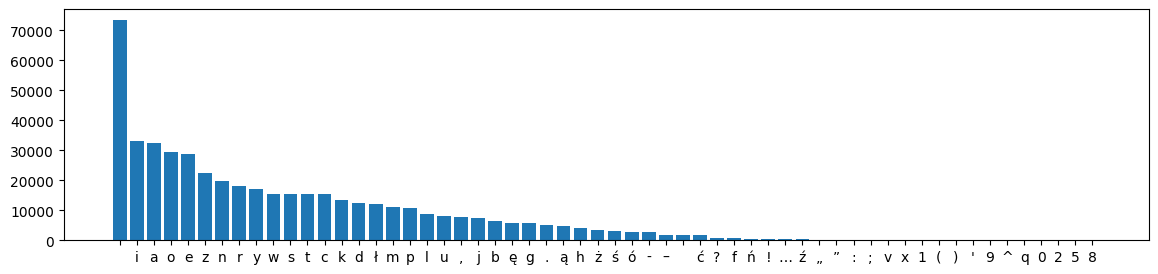

In [7]:
from collections import Counter

counter = Counter(text)
chars, counts = zip(*counter.most_common())
indices = np.arange(len(counts))


plt.figure(figsize=(14, 3))
plt.bar(indices, counts, 0.8)
plt.xticks(indices, [c for c in chars])
plt.show()

### Reprezentacja wektorowa
Każdemu ze znaków możemy przypisać jakąś liczbe i w ten sposób zakodować tekst w postaci numerycznej. Aby łatwo przechodzić z postaci numerycznej na tekstową i odwrotnie stwórzmy sobie pomocnicze słowniki:

In [8]:
char_indices = dict((c, i) for i, c in enumerate(vocab))
indices_char = dict((i, c) for i, c in enumerate(vocab))

### Generowanie sekwencji uczących
Będziemy tworzyć prosty model języka naturalnego, czyli model, który będzie generował kolejny znak na bazie wcześniejszej sekwencji znaków.

In [9]:
def make_sequences(text, max_length=40, step=3):
    sequences = []
    next_chars = []
    for i in range(0, len(text) - max_length, step):
        sequences.append(text[i : i + max_length])
        next_chars.append(text[i + max_length])
    return sequences, next_chars


sequences, next_chars = make_sequences(train_text)
sequences_test, next_chars_test = make_sequences(test_text, step=10)

print("nb train sequences:", len(sequences))
print("nb test sequences:", len(sequences_test))

nb train sequences: 144156
nb test sequences: 4802


Wymieszenia sekwencji aby nie podawać obok siebie sekwencji zawierających podobne sekwencje znaków:

In [10]:
from sklearn.utils import shuffle

sequences, next_chars = shuffle(sequences, next_chars, random_state=30)

Przykładowa sekwencja:

In [11]:
sequences[0]

'ężarowym włazie. musimy wyjść tym - jeże'

Kolejny znak to:

In [12]:
next_chars[0]

'l'

### Kodowanie one-hot
W modelu wykorzystamy proste kodowanie one-hot

In [13]:
max_length = 40
n_sequences = len(sequences)
n_sequences_test = len(sequences_test)
voc_size = len(vocab)

X = np.zeros((n_sequences, max_length, voc_size), dtype=np.float32)
y = np.zeros((n_sequences, voc_size), dtype=np.float32)

X_test = np.zeros((n_sequences_test, max_length, voc_size), dtype=np.float32)
y_test = np.zeros((n_sequences_test, voc_size), dtype=np.float32)

for i, sequence in enumerate(sequences):
    for t, char in enumerate(sequence):
        X[i, t, char_indices[char]] = 1
    y[i, char_indices[next_chars[i]]] = 1

for i, sequence in enumerate(sequences_test):
    for t, char in enumerate(sequence):
        X_test[i, t, char_indices[char]] = 1
    y_test[i, char_indices[next_chars_test[i]]] = 1

In [14]:
X.shape, y.shape

((144156, 40, 58), (144156, 58))

## Ćwiczenie 1:
### Model sieci rekurencyjnej
Stwórz model rekurencyjnej sieci neuronowej do prognozowania następnego znaku w sekwencji. Pamiętaj, że zakodowaliśmy znaki za pomocą metody one-hot.

In [15]:
from tensorflow import keras

In [16]:
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding

In [17]:
# twój model tutaj
vocab_size = 58
rnn_units = 128

x = Input(shape=(40, vocab_size))
l = LSTM(128, return_sequences=True)(x)
l = LSTM(128)(l)
o = Dense(voc_size, activation="softmax")(l)

model = Model(inputs=x, outputs=o)

model.summary()

I0000 00:00:1774998307.857217    8726 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 58)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 40, 128)        │        95,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 58)             │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,810 (917.23 KB)

 Trainable params: 234,810 (917.23 KB)

 Non-trainable params: 0 (0.00 B)

## Miara jakości prawdopodobieństwa
Do sprawdzenia czy model dobrze uczy się prawdopodobieńst kolejnego znaku można wykorzystać miarę [Perplexity](https://en.wikipedia.org/wiki/Perplexity)

In [18]:
def perplexity(y_true, y_pred):
    """
    y_true is one-hot encoded ground truth.
    y_pred is predicted likelihoods for each class.
    2 ** -mean(log2(p))
    """
    likelihoods = np.sum(y_pred * y_true, axis=1)
    return 2 ** -np.mean(np.log2(likelihoods))

Perplexity losowo zaicjalizowanego modelu

In [19]:
def model_perplexity(model, X, y, verbose=0):
    predictions = model.predict(X, verbose=verbose)
    return perplexity(y, predictions)

In [20]:
model_perplexity(model, X_test, y_test)

2026-04-01 01:05:10.032856: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


np.float32(57.995636)

### Uczenie modelu na małym podzbiorze zbioru trenującego
Przed rozpoczęciem uczenia upewnij się że masz uruchomione środowiesko wyposarzone w GPU inaczej będzie trzeba poczekać dłuższą chwile.

In [21]:
from keras.optimizers import Adam

model.compile(optimizer=Adam(), loss="categorical_crossentropy")

In [22]:
small_train = slice(0, None, 40)
hist = model.fit(X[small_train], y[small_train], batch_size=128, epochs=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 3.5756


Perplexity po krótkim uczeniu:

In [23]:
model_perplexity(model, X_test, y_test)

np.float32(27.646626)

Powinno być mniejsze niż poprzednio inaczej model niczego sie nie nauczył.

## Generowanie losowej próbki tekstu z modelu
Generujemy rekurencyjnie znak po znaku poprzez losowanie z odpowiednim prawdopodobieństwem

$$
p_{\theta}(c_n | c_{n-1}, c_{n-2}, \ldots, c_0) \cdot p_{\theta}(c_{n-1} | c_{n-2}, \ldots, c_0) \cdot \ldots \cdot p_{\theta}(c_{0})
$$

Parametr 'temperature' pozwala na usunięcie dodatkowej entropi z modelu.

#### Ćwiczenie 2:
Poniżej znajduje się kod generujący przykładowy tekst, spróbuj w prostych słowach opisać co i jak on tak na prawdę robi.

odp. ten kod bierze początek tekstu i generuje kolejne znaki jeden po drugim, za kazdym razem używając modelu i losowości

In [24]:
def sample_one(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probs = np.random.multinomial(1, preds, size=1)
    return np.argmax(probs)


def generate_text(model, seed_string, length=50, temperature=1.0):
    generated = seed_string
    prefix = seed_string

    for i in range(length):
        # Vectorize prefix string to feed as input to the model:
        x = np.zeros((1, max_length, voc_size))
        shift = max_length - len(prefix)
        for t, char in enumerate(prefix):
            x[0, t + shift, char_indices[char]] = 1.0

        preds = model.predict(x, verbose=0)[0]
        next_index = sample_one(preds, temperature)
        next_char = indices_char[next_index]

        generated += next_char
        prefix = prefix[1:] + next_char
    return generated

Przykład:

In [25]:
generate_text(model, "statek wbijał się ", temperature=0.1)

'statek wbijał się                                                   '

In [26]:
generate_text(model, "statek wbijał się ", temperature=0.8)

'statek wbijał się niiiiw ru eo, cotar er a aqwły esk awo     a głwu '

## Dalsze trenowanie
Wygenerowany poprzednio tekst, nie wygląda zbyt "czytelnie" a to dla tego, że model uczony był zbyt krótki i na niewielkim zbiorze danych. Pouczmy go więc dłużej. Wykonuj poniższą komórkę tyle razy aż generowane sekwencjie będą miały sens.

In [27]:
nb_epoch = 5
seed_strings = ["dziś jest wtorek "]

for epoch in range(nb_epoch):
    print("# Epoch {}/{}".format(epoch + 1, nb_epoch))
    model.fit(X, y, validation_split=0.1, batch_size=128, epochs=1, verbose=1)
    test_perplexity = model_perplexity(model, X_test, y_test)
    print("Perplexity na zbiorze testowym: {}".format(test_perplexity))

    for temperature in [0.1, 0.5, 1]:
        print("Przykładowy tekst dla temperatury {}:\n".format(temperature))
        for seed_string in seed_strings:
            print(generate_text(model, seed_string, temperature=temperature))
            print()

# Epoch 1/5


2026-04-01 01:05:25.471524: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1203987200 exceeds 10% of free system memory.
2026-04-01 01:05:26.417929: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1203987200 exceeds 10% of free system memory.


1014/1014 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 2.7704 - val_loss: 2.4041
Perplexity na zbiorze testowym: 11.957236289978027
Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek wieto powiedzie powiedzie się zanie powiedzie porz

Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek trzynie potakie nam towy wadnie mie się dodowie wa

Przykładowy tekst dla temperatury 1:

dziś jest wtorek pujeta miorze! watę… miam sier zabałaom zawajiłysz

# Epoch 2/5


2026-04-01 01:06:00.469425: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1203987200 exceeds 10% of free system memory.
2026-04-01 01:06:02.054171: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1203987200 exceeds 10% of free system memory.


1014/1014 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - loss: 2.3257 - val_loss: 2.2367
Perplexity na zbiorze testowym: 10.178764343261719
Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek wiedzie z przednie z powiedzie z podziedzie storze

Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek powiedział pobylena zczeznaczy mapał w goch podzie

Przykładowy tekst dla temperatury 1:

dziś jest wtorek wastjamia zogajsku nażu, stornnien wy tąw poprzesł

# Epoch 3/5


2026-04-01 01:06:36.382211: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1203987200 exceeds 10% of free system memory.


1014/1014 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - loss: 2.1892 - val_loss: 2.1348
Perplexity na zbiorze testowym: 9.307827949523926
Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek powiedział się w powiedzie się nie powiedział się 

Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek strzynini i sotory to mowiegnie z nie wyżeli powie

Przykładowy tekst dla temperatury 1:

dziś jest wtorek moszłu powieli o bióną pić ddzigli powiedziej. że 

# Epoch 4/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - loss: 2.0940 - val_loss: 2.0599
Perplexity na zbiorze testowym: 8.691943168640137
Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek wystał się za przed się wystał się wystał się w po

Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek rakieny konie szarawały się zagroda wszystkie powi

Przykładowy tekst dla temperatury 1:

dziś jest wtorek ziłor skierawów rażynie krodza jakieczychł, dnarne

# Epoch 5/5
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - loss: 2.0156 - val_lo

## Ćwiczenie 3
Rozbuduj model sieci neuronowej z wykorzystaniem warstwy Embedding, zastępując nią kodowanie one-hot. Zwizualizowac warstwe emmbeding.

In [28]:
import numpy as np
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding
from keras.optimizers import Adam

vocab_size = 58
max_length = 40
embedding_dim = 16
rnn_units = 128

x = Input(shape=(max_length,))
e = Embedding(input_dim=vocab_size, output_dim=embedding_dim, name="embedding_layer")(x)
l = LSTM(128, return_sequences=True)(e)
l = LSTM(128)(l)
o = Dense(vocab_size, activation="softmax")(l)

model = Model(inputs=x, outputs=o)
model.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy"
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_layer (Embedding)     │ (None, 40, 16)         │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 40, 128)        │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 58)             │         7,482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,234 (836.85 KB)

 Trainable params: 214,234 (836.85 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# text = "to jest jakis tekst ..."
chars = sorted(list(set(text)))
voc_size = len(chars)

char_indices = {c: i for i, c in enumerate(chars)}
indices_char = {i: c for i, c in enumerate(chars)}

In [40]:
text_as_int = [char_indices[c] for c in text]

In [42]:
max_length = 40
step = 1

X_data = []
y_data = []

for i in range(0, len(text_as_int) - max_length, step):
    X_data.append(text_as_int[i:i + max_length])
    y_data.append(text_as_int[i + max_length])

X_data = np.array(X_data, dtype=np.int32)
y_data = np.array(y_data, dtype=np.int32)

print(X_data.shape)
print(y_data.shape)

(480524, 40)
(480524,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42
)

In [44]:
def perplexity_sparse(y_true, y_pred, eps=1e-12):
    probs = y_pred[np.arange(len(y_true)), y_true]
    probs = np.clip(probs, eps, 1.0)
    return np.exp(-np.mean(np.log(probs)))

def model_perplexity(model, X, y, verbose=0):
    predictions = model.predict(X, verbose=verbose)
    return perplexity_sparse(y, predictions)

In [46]:
def sample_one(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(np.clip(preds, 1e-12, 1.0)) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

def generate_text(model, seed_string, length=50, temperature=1.0):
    generated = seed_string
    prefix = seed_string

    for _ in range(length):
        prefix_indices = [char_indices[c] for c in prefix]

        x = np.array([prefix_indices], dtype=np.int32)

        preds = model.predict(x, verbose=0)[0]
        next_index = sample_one(preds, temperature)
        next_char = indices_char[next_index]

        generated += next_char
        prefix = prefix[1:] + next_char

    return generated

In [47]:
nb_epoch = 5
seed_strings = ["dziś jest wtorek i pada deszcz za okn"]

for epoch in range(nb_epoch):
    print(f"# Epoch {epoch + 1}/{nb_epoch}")
    
    model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        batch_size=128,
        epochs=1,
        verbose=1
    )
    
    test_perplexity = model_perplexity(model, X_test, y_test)
    print("Perplexity na zbiorze testowym:", test_perplexity)

    for temperature in [0.1, 0.5, 1.0]:
        print(f"\nPrzykładowy tekst dla temperatury {temperature}:\n")
        for seed_string in seed_strings:
            print(generate_text(model, seed_string, temperature=temperature))
            print()

# Epoch 1/5
2703/2703 ━━━━━━━━━━━━━━━━━━━━ 68s 24ms/step - loss: 2.4771 - val_loss: 2.1808
Perplexity na zbiorze testowym: 8.847935

Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek i pada deszcz za oknierział się nie wierział się wiedział się w wiedzi


Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek i pada deszcz za okniał wiechał - przemiedział się się zaszydziało się


Przykładowy tekst dla temperatury 1.0:

dziś jest wtorek i pada deszcz za oknik. pojedział i do wosłą!  – taz ogsoczytła.  – cz

# Epoch 2/5
2703/2703 ━━━━━━━━━━━━━━━━━━━━ 63s 23ms/step - loss: 2.0364 - val_loss: 1.9406
Perplexity na zbiorze testowym: 6.9807863

Przykładowy tekst dla temperatury 0.1:

dziś jest wtorek i pada deszcz za okniejsze w nie wiem zachonie w nie powiedział się w 


Przykładowy tekst dla temperatury 0.5:

dziś jest wtorek i pada deszcz za okniema z grzych stroną w nich czarnych wychunine roz


Przykładowy tekst dla temperatury 1.0:

dziś jest wtorek i pada deszcz za oknerwać k

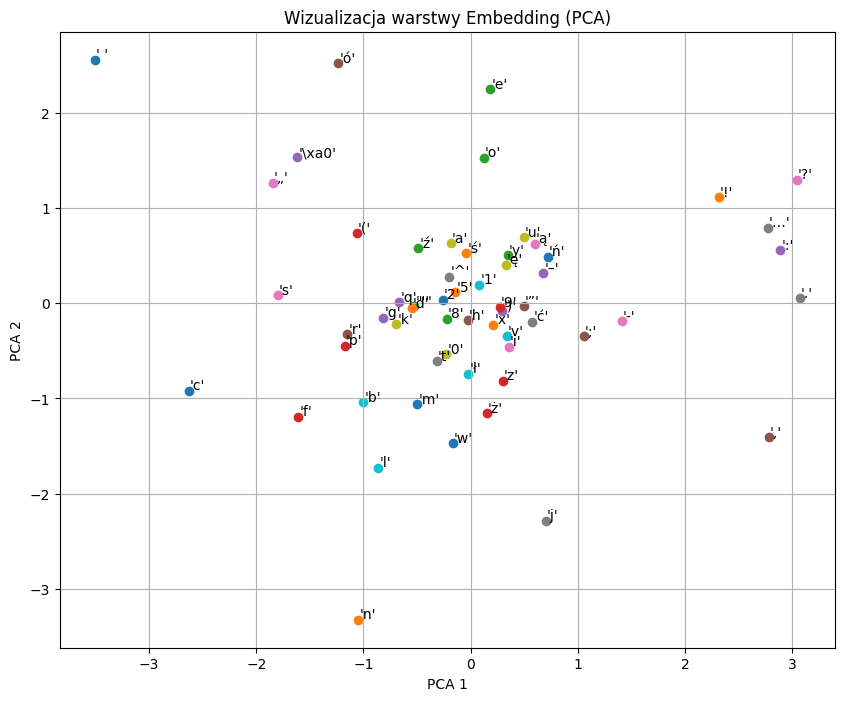

In [48]:
from sklearn.decomposition import PCA

embedding_weights = model.get_layer("embedding_layer").get_weights()[0]

pca = PCA(n_components=2)
embedding_2d = pca.fit_transform(embedding_weights)

plt.figure(figsize=(10, 8))
for i, char in indices_char.items():
    x, y = embedding_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, repr(char), fontsize=10)

plt.title("Wizualizacja warstwy Embedding (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()